# Analyse Superstore

Ce notebook charge le jeu de données, le prétraite, puis répond aux questions avec des agrégations pandas et des visualisations.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement et prétraitement minimal
df = pd.read_excel("US Superstore data.xls")
df = df.dropna(subset=["State", "City", "Customer Name", "Sales", "Profit"])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Quels sont les États qui enregistrent le plus de ventes ?

Top 10 États par chiffre d'affaires :
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


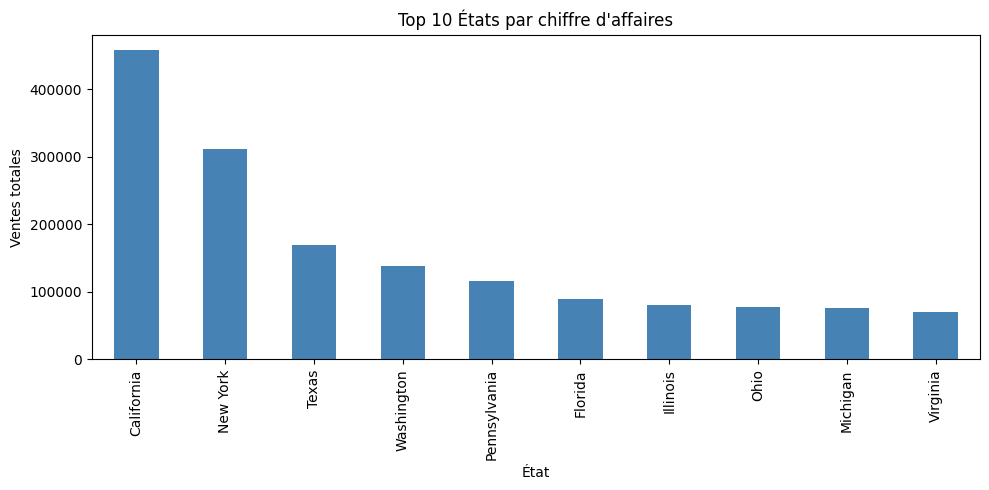

In [10]:
sales_by_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print("Top 10 États par chiffre d'affaires :")
print(sales_by_state.head(10))

plt.figure(figsize=(10, 5))
sales_by_state.head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 États par chiffre d'affaires")
plt.xlabel("État")
plt.ylabel("Ventes totales")
plt.tight_layout()
plt.show()

## Quelle est la différence entre New York et la Californie ?

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


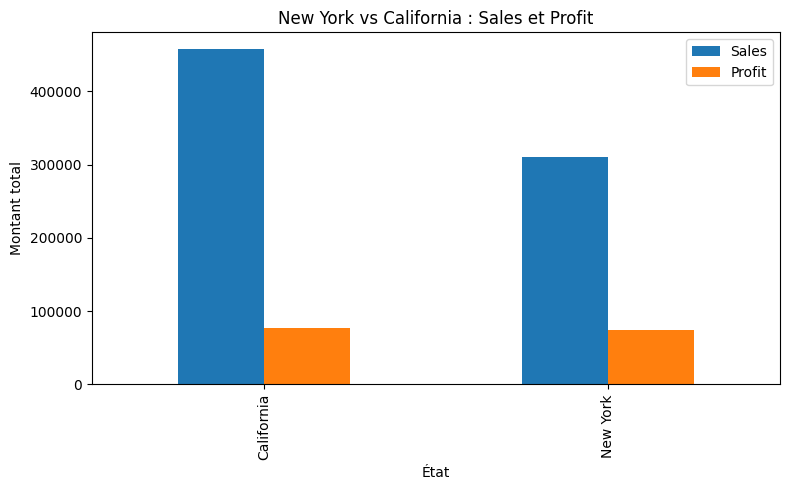

In [11]:
ny_ca = df[df['State'].isin(['New York', 'California'])]
state_summary = ny_ca.groupby('State')[['Sales', 'Profit']].sum()
print(state_summary)

state_summary.plot(kind='bar', figsize=(8, 5))
plt.title("New York vs California : Sales et Profit")
plt.xlabel("État")
plt.ylabel("Montant total")
plt.tight_layout()
plt.show()

## Qui est un client exceptionnel à New York ?

In [12]:
clients_ny = (
    df[df['State'] == 'New York']
    .groupby('Customer Name')
    .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Customer Name', 'count'))
    .sort_values('Profit', ascending=False)
)
print(clients_ny.head(5))

                      Sales     Profit  Orders
Customer Name                                 
Tom Ashbrook      13723.498  4599.2073       5
Keith Dawkins      5854.194  2510.8903       6
Karen Daniels      6241.282  2283.0463       6
Nathan Mautz       4821.292  2247.1904       6
Tom Boeckenhauer   6999.960  2239.9872       1


## Existe-t-il des différences de rentabilité entre les États ?

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


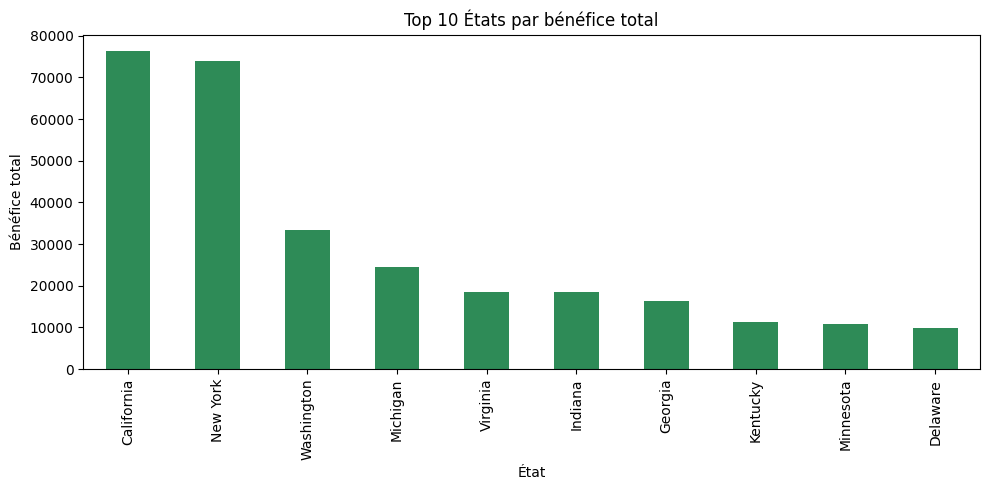

In [13]:
profit_by_state = df.groupby('State')['Profit'].sum().sort_values(ascending=False)
print(profit_by_state.head(10))

plt.figure(figsize=(10, 5))
profit_by_state.head(10).plot(kind='bar', color='seagreen')
plt.title("Top 10 États par bénéfice total")
plt.xlabel("État")
plt.ylabel("Bénéfice total")
plt.tight_layout()
plt.show()

## Peut-on appliquer le principe de Pareto aux clients et aux bénéfices ?

Les 20% premiers clients génèrent 81.43% des bénéfices.
Conclusion Pareto : Oui


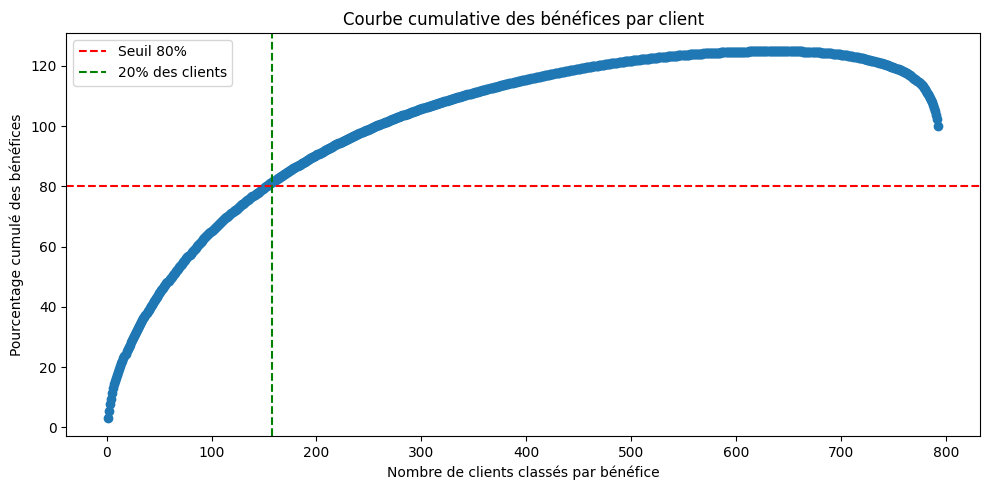

In [14]:
client_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)
client_profit_cumsum_pct = client_profit.cumsum() / client_profit.sum() * 100
threshold_index = max(1, int(len(client_profit) * 0.2))
profit_share_top_20 = client_profit.head(threshold_index).sum() / client_profit.sum() * 100

print(f"Les 20% premiers clients génèrent {profit_share_top_20:.2f}% des bénéfices.")
print("Conclusion Pareto :", "Oui" if profit_share_top_20 >= 80 else "Non")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(client_profit_cumsum_pct) + 1), client_profit_cumsum_pct.values, marker='o', linewidth=1)
plt.axhline(80, color='red', linestyle='--', label='Seuil 80%')
plt.axvline(threshold_index, color='green', linestyle='--', label='20% des clients')
plt.title("Courbe cumulative des bénéfices par client")
plt.xlabel("Nombre de clients classés par bénéfice")
plt.ylabel("Pourcentage cumulé des bénéfices")
plt.legend()
plt.tight_layout()
plt.show()

## Quelles sont les 20 premières villes en termes de chiffre d'affaires et de bénéfice ?

Top 20 villes par chiffre d'affaires :
                     Sales      Profit
City                                  
New York City  256368.1610  62036.9837
Los Angeles    175851.3410  30440.7579
Seattle        119540.7420  29156.0967
San Francisco  112669.0920  17507.3854
Philadelphia   109077.0130 -13837.7674
Houston         64504.7604 -10153.5485
Chicago         48539.5410  -6654.5688
San Diego       47521.0290   6377.1960
Jacksonville    44713.1830  -2323.8350
Springfield     43054.3420   6200.6974
Detroit         42446.9440  13181.7908
Columbus        38706.2430   5897.1013
Newark          28576.1190   5793.7588
Columbia        25283.3240   5606.1167
Lafayette       25036.2000  10018.3876
Jackson         24963.8580   7581.6828
San Antonio     21843.5280  -7299.0502
Burlington      21668.0820  -3622.8772
Arlington       20214.5320   4169.6969
Dallas          20131.9322  -2846.5257

Top 20 villes par bénéfice :
                    Sales      Profit
City                               

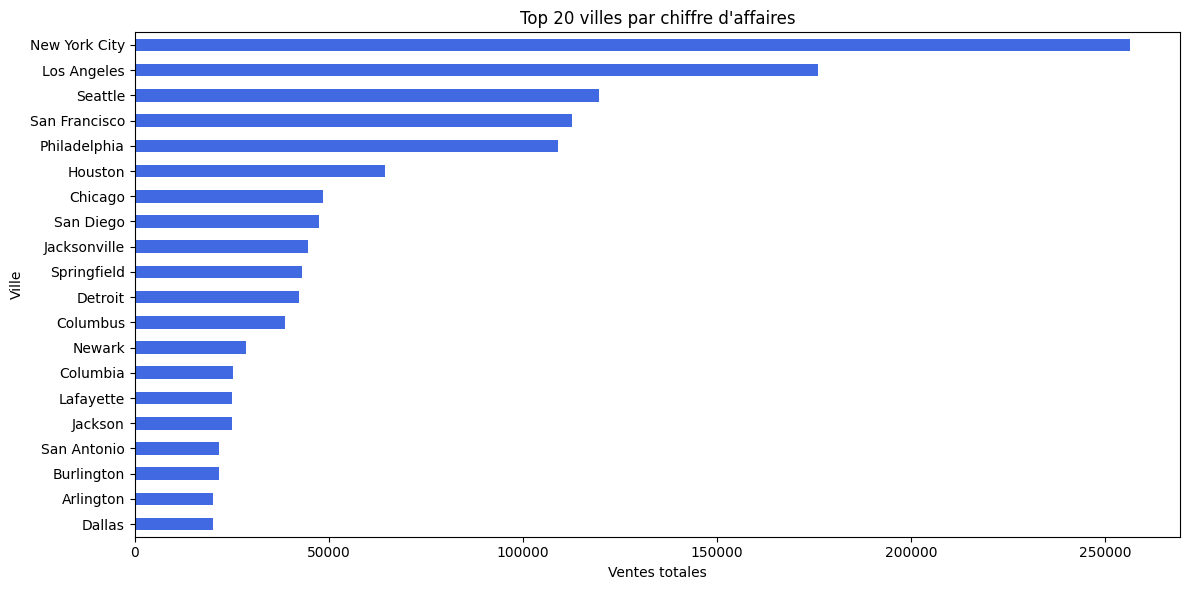

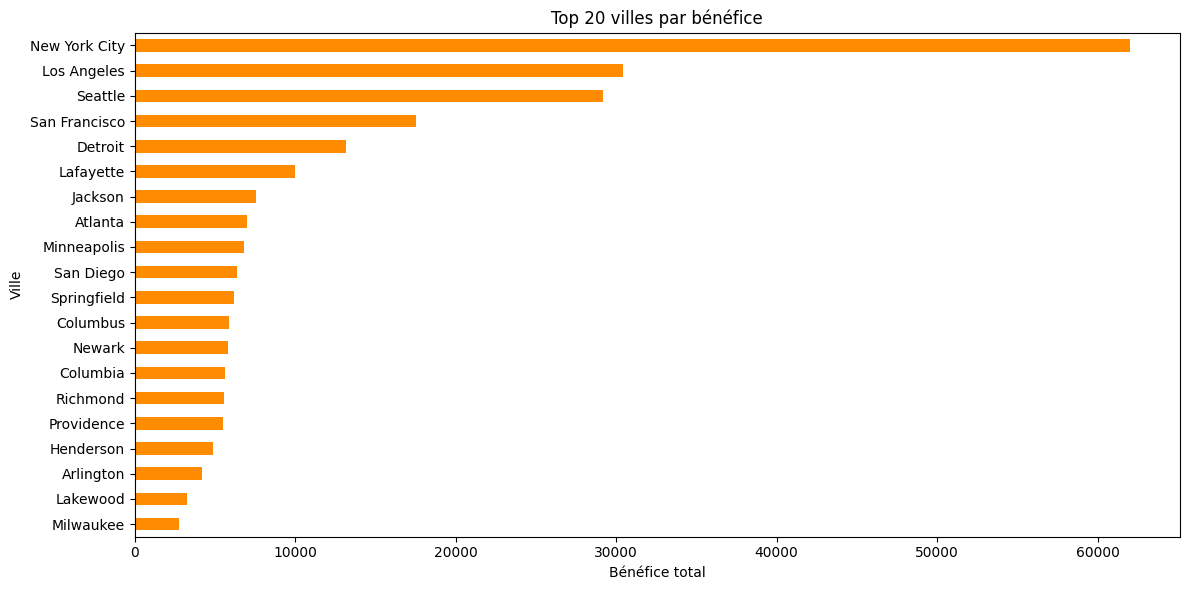

In [15]:
city_summary = df.groupby('City')[['Sales', 'Profit']].sum()
top_20_cities_sales = city_summary.sort_values('Sales', ascending=False).head(20)
top_20_cities_profit = city_summary.sort_values('Profit', ascending=False).head(20)

print("Top 20 villes par chiffre d'affaires :")
print(top_20_cities_sales)

print("\nTop 20 villes par bénéfice :")
print(top_20_cities_profit)

plt.figure(figsize=(12, 6))
top_20_cities_sales['Sales'].sort_values().plot(kind='barh', color='royalblue')
plt.title("Top 20 villes par chiffre d'affaires")
plt.xlabel("Ventes totales")
plt.ylabel("Ville")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
top_20_cities_profit['Profit'].sort_values().plot(kind='barh', color='darkorange')
plt.title("Top 20 villes par bénéfice")
plt.xlabel("Bénéfice total")
plt.ylabel("Ville")
plt.tight_layout()
plt.show()

## Quels sont les 20 meilleurs clients en termes de ventes ?

Top 20 clients en termes de ventes :
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


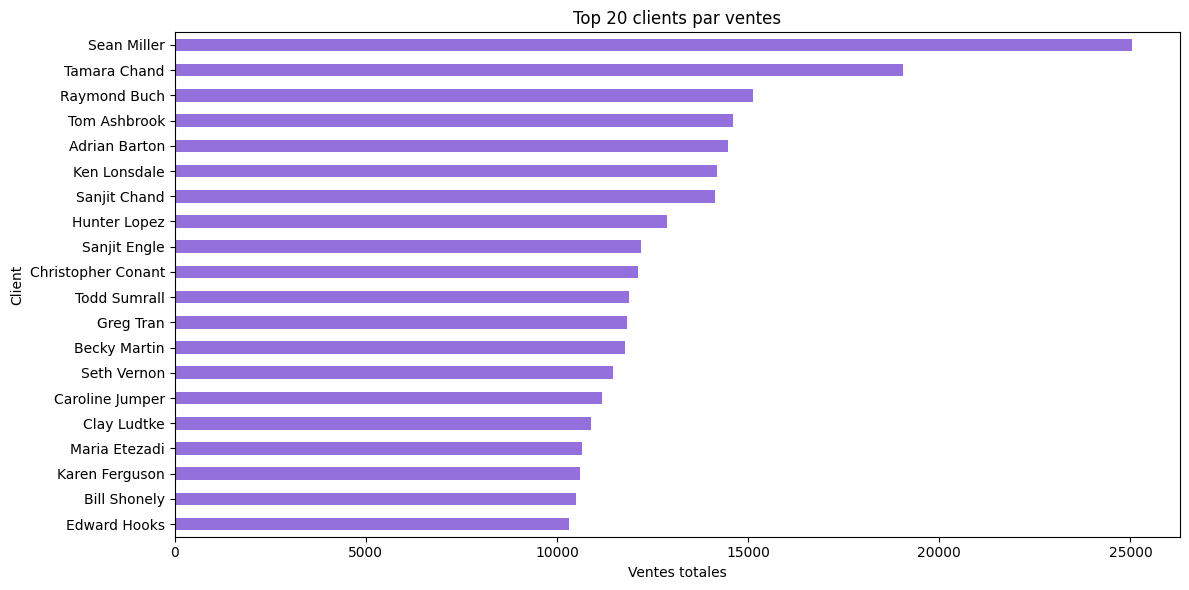

Les 20% premiers clients génèrent 47.96% des ventes.
Conclusion Pareto ventes : Non


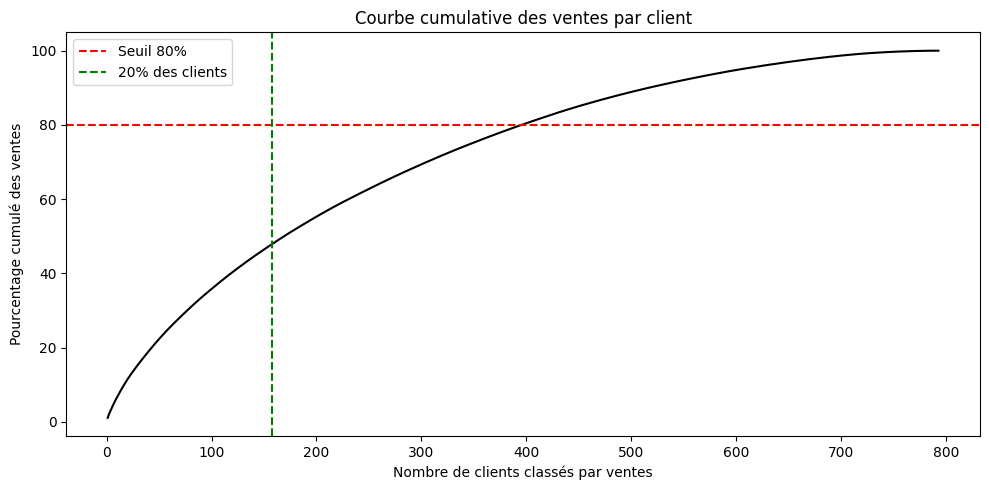

In [16]:
client_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
print("Top 20 clients en termes de ventes :")
print(client_sales.head(20))

plt.figure(figsize=(12, 6))
client_sales.head(20).sort_values().plot(kind='barh', color='mediumpurple')
plt.title("Top 20 clients par ventes")
plt.xlabel("Ventes totales")
plt.ylabel("Client")
plt.tight_layout()
plt.show()

sales_cumsum_pct = client_sales.cumsum() / client_sales.sum() * 100
threshold_index_sales = max(1, int(len(client_sales) * 0.2))
sales_share_top_20 = client_sales.head(threshold_index_sales).sum() / client_sales.sum() * 100

print(f"Les 20% premiers clients génèrent {sales_share_top_20:.2f}% des ventes.")
print("Conclusion Pareto ventes :", "Oui" if sales_share_top_20 >= 80 else "Non")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(sales_cumsum_pct) + 1), sales_cumsum_pct.values, color='black')
plt.axhline(80, color='red', linestyle='--', label='Seuil 80%')
plt.axvline(threshold_index_sales, color='green', linestyle='--', label='20% des clients')
plt.title("Courbe cumulative des ventes par client")
plt.xlabel("Nombre de clients classés par ventes")
plt.ylabel("Pourcentage cumulé des ventes")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion et recommandations marketing

Les analyses montrent qu'il faut privilégier les zones où les profits sont les plus élevés, en particulier les États et villes qui apparaissent dans les premiers rangs des classements de ventes et de bénéfices. Les clients qui génèrent une part importante du bénéfice total doivent être ciblés en priorité, car le principe de Pareto est vérifié pour les bénéfices mais pas pour les ventes. Pour améliorer la performance marketing, il est donc pertinent de concentrer les actions sur les villes rentables, de fidéliser les meilleurs clients et d'éviter de disperser les efforts sur les marchés peu profitables.